In [110]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point

np.random.seed(43)
# Barcodes
true_barcodes = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Timepoints
timepoints = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/timepoints.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Lineages
lineages = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)


x_bc_3d = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_bc.npy"
)

# Flatten
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

# Fate feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# Fate dataframe
df_fate = pd.DataFrame(
    np.log2(x_bc_2d + 1),
    index=true_barcodes,
    columns=fate_features
)

## CHANGING O.5 TO 0.8 - SAME VAR USED IN NMF. used 0.0 for prev analysis. going to 08 for 1-1 comparison of no. of overlapping genes

df_rna = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_rna_variance_0.80.csv",
    index_col=0
)

df_adt = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_adt.csv",
    index_col=0
)

# Force matching barcodes
df_rna.index = true_barcodes
df_adt.index = true_barcodes

# getting rid of zero var cells - 
df_rna = df_rna.loc[:, df_rna.var() > 0]
df_adt = df_adt.loc[:, df_adt.var() > 0]
df_fate = df_fate.loc[:, df_fate.var() > 0]

print(f"Remaining RNA features: {df_rna.shape[1]}")
print(f"Remaining ADT features: {df_adt.shape[1]}")
print(f"Remaining Fate features: {df_fate.shape[1]}")


feat_rna = df_rna.columns.tolist()
feat_adt = df_adt.columns.tolist()
feat_fate = df_fate.columns.tolist()


mat_rna = df_rna.values.astype(np.float64)
mat_adt = df_adt.values.astype(np.float64)
mat_fate = df_fate.values.astype(np.float64)

# Nested structure:
# views -> groups
data_nested_matrix = [
    [mat_rna],
    [mat_adt],
    [mat_fate]
]
assert list(df_rna.index) == list(df_adt.index)
assert list(df_rna.index) == list(df_fate.index)

# Run MOFA

ent = entry_point()

ent.set_data_options(
    scale_views=True
)

ent.set_data_matrix(
    data_nested_matrix,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["RNA", "ADT", "Fate_Tracking"],
    groups_names=["single_group"],
    samples_names=[true_barcodes],
    features_names=[feat_rna, feat_adt, feat_fate]
)

ent.set_model_options(
    factors=15,
    spikeslab_weights=True
)

ent.set_train_options(
    convergence_mode="medium",
    iter=1000,
    verbose=True,
    seed=43,
    dropR2=0.01
)

ent.build()
ent.run()


# ent.save(
#     "zero_var_mofa.hdf5",
#     save_data=True
# )

Remaining RNA features: 4674
Remaining ADT features: 163
Remaining Fate features: 40

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Successfully loaded view='RNA' group='single_group' with N=112 samples and D=4674 features...
Successfully loaded view='ADT' group='single_group' with N=112 samples and D=163 features...
Successfully loaded view='Fate_Tracking' group='single_group' with N=112 samples 

In [ ]:
#adata = np.load("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_bc.npy")
factor_df
df_fate



,D7\n1_cDC1\n1,D7\n1_Lymph\n2,D7\n1_Rest\n3,D7\n1_Mast\n4,D7\n1_cDC2\n5,D7\n1_Ery\n6,D7\n1_pDC\n7,D7\n1_Mye,D10\n2_cDC1\n1,D10\n2_Lymph\n2,...,D17\n4_pDC\n7,D17\n4_Mye,D21_cDC1\n1,D21_Lymph\n2,D21_Rest\n3,D21_Mast\n4,D21_cDC2\n5,D21_Ery\n6,D21_pDC\n7,D21_Mye
AAAGATCGCACCATT_U\n1,2.589548,2.536310,2.970140,0.000000,2.793895,0.000000,0.000000,0.000000,2.732550,2.817935,...,0.000000,2.975918,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,3.015186
AAAGATGCGTAGGAT_U\n2,0.000000,2.670886,3.138374,0.584604,0.445928,2.163452,2.873836,2.189977,2.484596,3.282449,...,2.896824,3.466243,3.220668,3.154701,2.989374,3.363903,2.435736,0.0,3.020210,3.492179
AACCAATCGAAGTAT_U\n3,0.000000,0.000000,0.000000,0.000000,2.718204,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
AAGCCATGGTTCATA_U\n4,0.000000,2.359389,2.066368,0.000000,2.835975,0.000000,2.559675,3.082061,2.921511,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
AATGAAACAATCTAT_U\n5,0.000000,0.000000,2.656656,2.725216,0.000000,2.879937,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCTGACTCTGGGTCT_V\n108,0.000000,0.000000,3.137578,3.235946,3.342052,2.830527,2.944027,2.824725,0.000000,0.618664,...,0.000000,3.100264,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,3.131994
GCTGATTGTCCAAGA_V\n109,2.628018,2.909495,3.390362,2.504360,2.728799,3.013044,2.920328,3.183916,0.622129,3.447113,...,3.054374,3.571751,3.081093,3.393522,3.349053,3.265705,0.000000,0.0,2.350983,3.566377
TATCTTCCTGAATGA_V\n110,0.000000,0.000000,0.000000,0.000000,2.846483,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
TCTCATGGAGCAACT_V\n111,0.000000,0.000000,0.000000,2.551424,2.834383,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


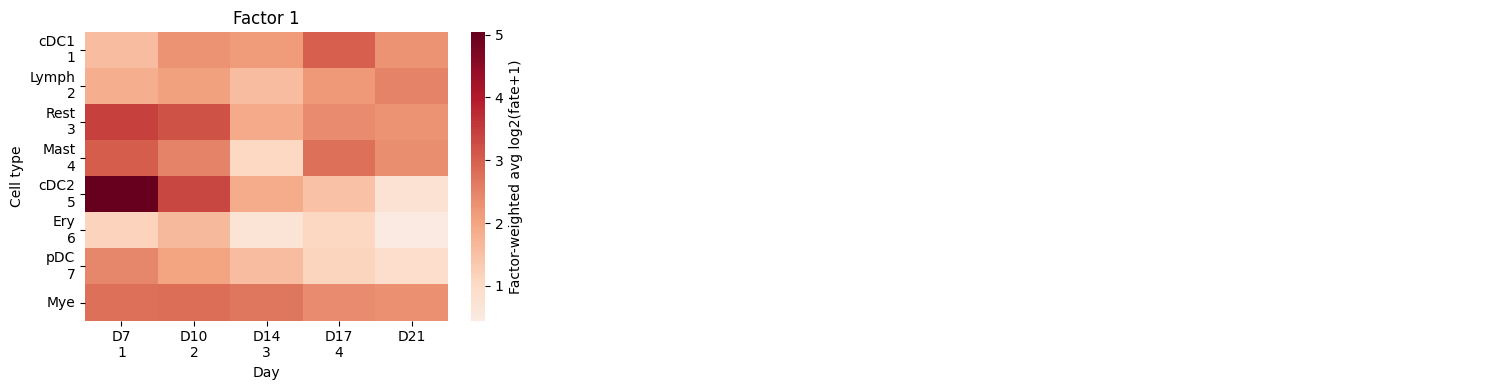

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Z = ent.model.getExpectations()["Z"]["E"]

if Z.shape[0] != len(true_barcodes):
    Z = Z.T
assert Z.shape[0] == len(true_barcodes)

X_lineage = x_bc_3d  # barcodes x timepoints x lineages, same order as true_barcodes
n_factors = Z.shape[1]

ncols = 3
nrows = int(np.ceil(n_factors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.ravel(axes)

for k in range(n_factors):
    weights = Z[:, k]
    weights = weights - weights.min()   # shift so weights are non-negative
    weights = weights / weights.sum()   # normalize to sum to 1

    # weighted avg over barcodes -> (timepoints, lineages)
    avg = np.tensordot(weights, X_lineage, axes=(0, 0))

    sns.heatmap(
        avg.T,                  # -> (lineages, timepoints), so day=x, celltype=y
        ax=axes[k],
        cmap="RdBu_r",
        center=0,
        xticklabels=timepoints,
        yticklabels=lineages,
        cbar_kws={"label": "Factor-weighted avg log2(fate+1)"},
    )
    axes[k].set_title(f"Factor {k+1}")
    axes[k].set_xlabel("Day")
    axes[k].set_ylabel("Cell type")

for ax in axes[n_factors:]:
    ax.axis("off")

plt.tight_layout()

## applying varimax rotation to a copy of mofa since factors do not seem orthognal to each other: 
# VARIMAX
#
#


In [ ]:
## n
exp = ent.model.getExpectations()
print(type(exp["W"]))
if isinstance(exp["W"], dict):
    print(exp["W"].keys())
    print(type(exp["W"]["E"]), len(exp["W"]["E"]))
else:
    print(len(exp["W"]), type(exp["W"][0]))

<class 'list'>
3 <class 'dict'>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.rotator import Rotator

# --- 1) Pull Z and W for every view ---
exp = ent.model.getExpectations()

Z_orig = exp["Z"]["E"] if isinstance(exp["Z"], dict) else exp["Z"]

# W is a list of per-view dicts, each with an "E" key
W_list_orig = [w["E"] for w in exp["W"]]
  # list: [W_rna, W_adt, W_fate]

view_names = ["RNA", "ADT", "Fate_Tracking"]
data_list = [mat_rna, mat_adt, mat_fate]  # original matrices, same order as views_names

if Z_orig.shape[0] != len(true_barcodes):
    Z_orig = Z_orig.T

# --- 2) Concatenate loadings across ALL views before rotating ---
W_concat = np.concatenate(W_list_orig, axis=0)  # (total_features x factors)

rotator = Rotator(method="varimax")
W_concat_rot = rotator.fit_transform(W_concat)
R = rotator.rotation_
Z_rot = Z_orig @ R

# --- 3) Split rotated loadings back into per-view chunks ---
split_idx = np.cumsum([w.shape[0] for w in W_list_orig])[:-1]
W_rot_list = np.split(W_concat_rot, split_idx, axis=0)

print("Z_rot:", Z_rot.shape)
for name, w in zip(view_names, W_rot_list):
    print(f"W_rot[{name}]:", w.shape)

ValueError: too many values to unpack (expected 2)

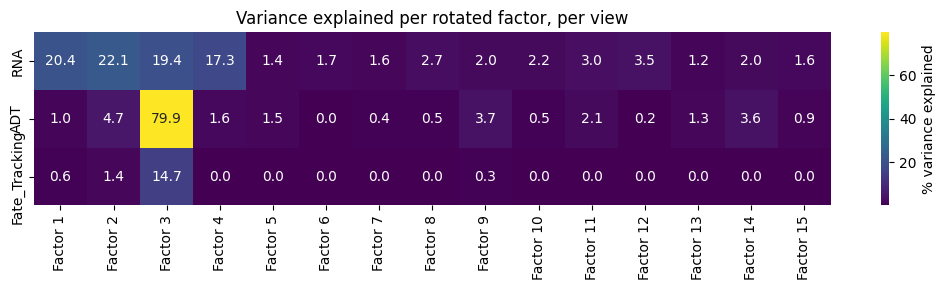

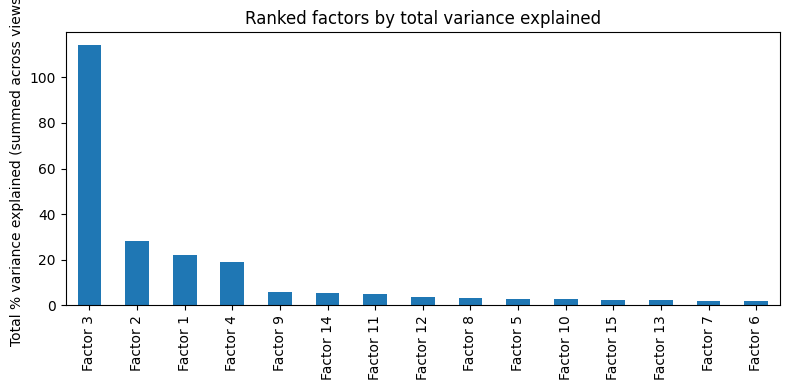

In [111]:
def r2_per_factor(Y, Z, W):
    """% variance of Y explained by each factor individually."""
    Y_c = Y - Y.mean(axis=0, keepdims=True)
    ss_tot = np.sum(Y_c ** 2)
    r2s = []
    for k in range(Z.shape[1]):
        Y_pred_k = np.outer(Z[:, k], W[:, k])
        ss_k = np.sum(Y_pred_k ** 2)
        r2s.append(100 * ss_k / ss_tot)
    return np.array(r2s)

n_factors = Z_rot.shape[1]
r2_matrix = np.zeros((len(view_names), n_factors))

for i, (Y, W) in enumerate(zip(data_list, W_rot_list)):
    r2_matrix[i, :] = r2_per_factor(Y, Z_rot, W)

r2_df = pd.DataFrame(
    r2_matrix,
    index=view_names,
    columns=[f"Factor {k+1}" for k in range(n_factors)]
)

# Heatmap: variance explained per factor, per view
plt.figure(figsize=(0.5 * n_factors + 3, 3))
sns.heatmap(r2_df, cmap="viridis", annot=True, fmt=".1f", cbar_kws={"label": "% variance explained"})
plt.title("Variance explained per rotated factor, per view")
plt.tight_layout()
plt.show()

# Bar plot: total variance explained per factor (summed across views), sorted
total_r2 = r2_df.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
total_r2.plot(kind="bar")
plt.ylabel("Total % variance explained (summed across views)")
plt.title("Ranked factors by total variance explained")
plt.tight_layout()
plt.show()

fate riving most variance in data by leages and miles. 

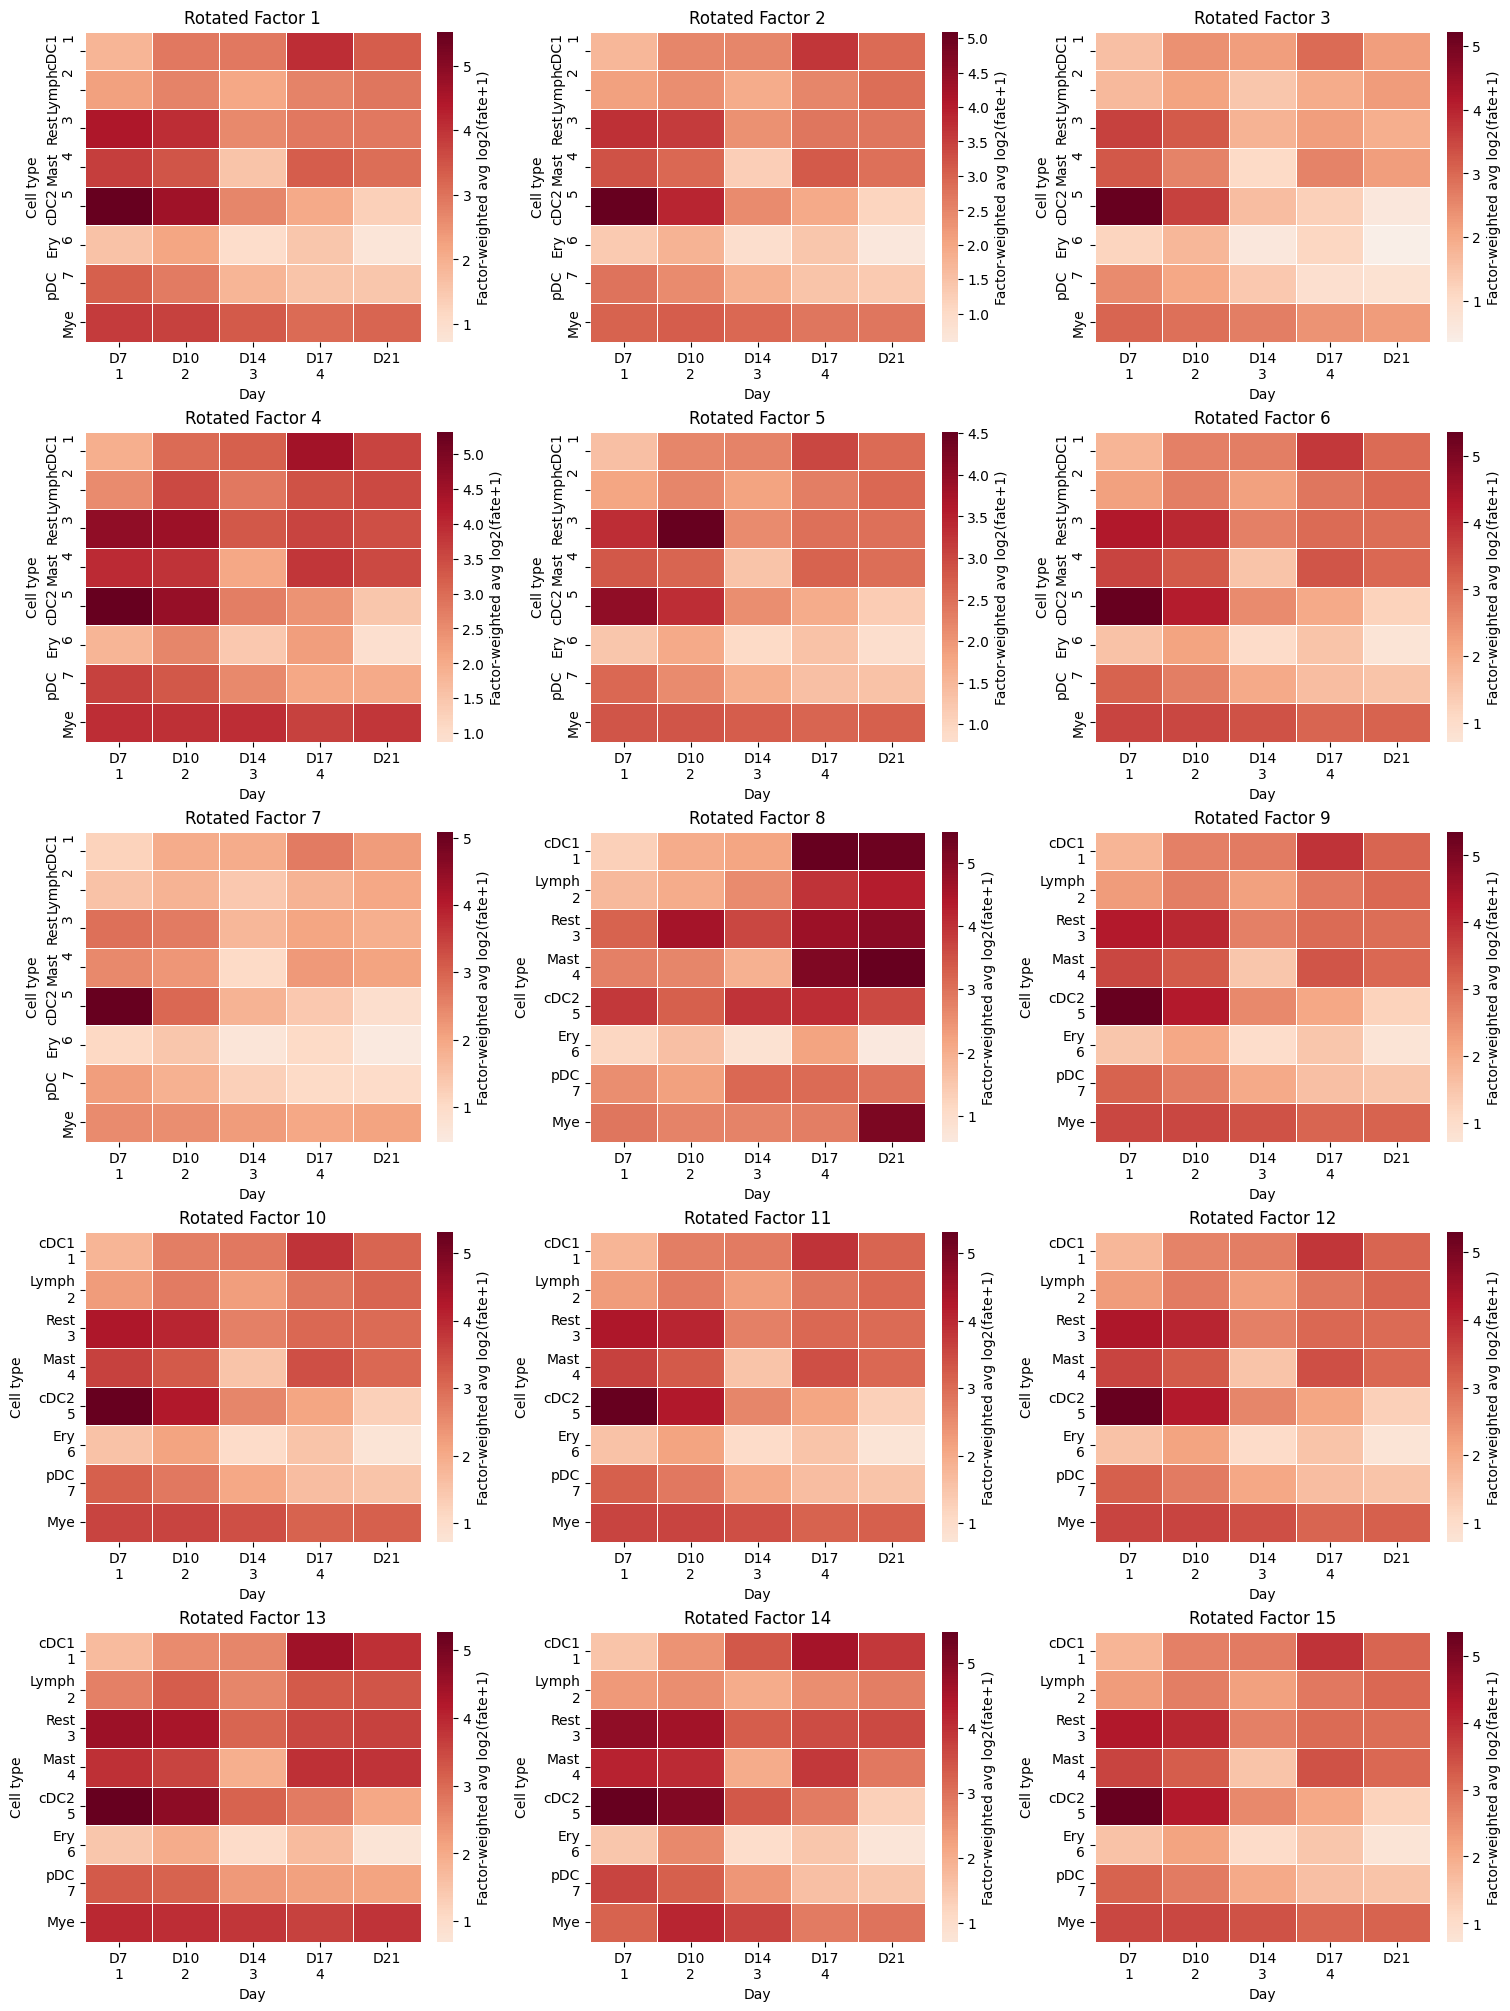

In [112]:
# plots post rotation
X_lineage = x_bc_3d  # barcodes x timepoints x lineages, same order as true_barcodes
n_factors = Z_rot.shape[1]

ncols = 3
nrows = int(np.ceil(n_factors / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True
)
axes = np.ravel(axes)

for k in range(n_factors):
    weights = Z_rot[:, k]
    weights = weights - weights.min()
    weights = weights / weights.sum()

    avg = np.tensordot(weights, X_lineage, axes=(0, 0))  # -> (timepoints, lineages)

    sns.heatmap(
        avg.T,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        square=False,
        ax=axes[k],
        xticklabels=timepoints,
        yticklabels=lineages,
        cbar_kws={"label": "Factor-weighted avg log2(fate+1)"},
    )
    axes[k].set_title(f"Rotated Factor {k+1}")
    axes[k].set_xlabel("Day")
    axes[k].set_ylabel("Cell type")

for ax in axes[n_factors:]:
    ax.axis("off")

plt.show()

## finding matching factors
using one to one overlap of factors

In [113]:
nmf_loadings = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_rna_loadings.npy",
    allow_pickle=True
)

nmf_activities = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_activities.npy",
    allow_pickle=True
)

nmf_genes = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/files/nmf_genes.csv",
).iloc[:, 0].values
print("nmf_loadings shape:", nmf_loadings.shape)
print("nmf_activities shape:", nmf_activities.shape)
print("nmf_genes shape:", nmf_genes.shape)
print("nmf_genes sample:", nmf_genes[:5])

print("is nmf_loadings.shape[0] != len(nmf_genes)?",nmf_loadings.shape[0] != len(nmf_genes))

nmf_loadings shape: (1714, 16)
nmf_activities shape: (822, 16)
nmf_genes shape: (1714,)
nmf_genes sample: ['HES4' 'ISG15' 'TNFRSF18' 'UTS2' 'ERRFI1']
is nmf_loadings.shape[0] != len(nmf_genes)? False


Common genes: 1015 (NMF had 1714, MOFA RNA had 4674)


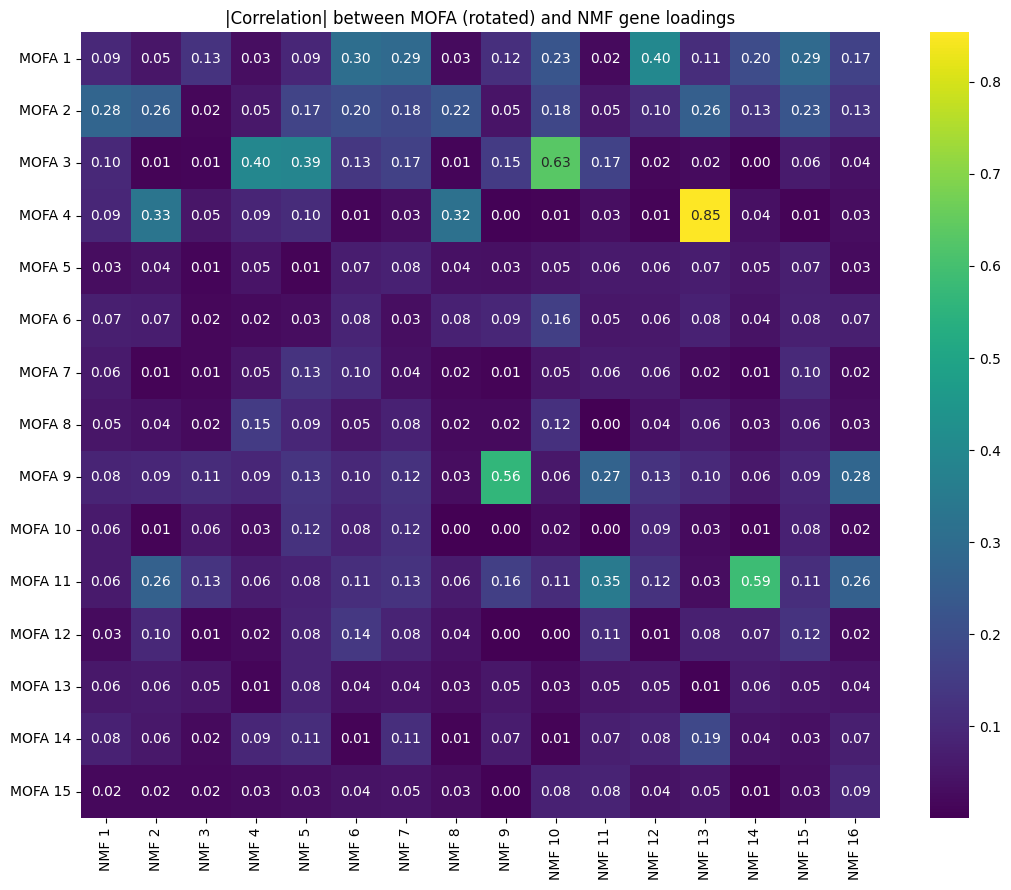

   MOFA_factor NMF_factor  similarity
3       MOFA 4     NMF 13    0.853823
2       MOFA 3     NMF 10    0.632000
10     MOFA 11     NMF 14    0.585382
8       MOFA 9      NMF 9    0.560634
0       MOFA 1     NMF 12    0.397773
1       MOFA 2      NMF 1    0.275995
7       MOFA 8      NMF 4    0.147608
11     MOFA 12      NMF 6    0.138702
9      MOFA 10      NMF 5    0.122882
13     MOFA 14      NMF 7    0.112576
6       MOFA 7     NMF 15    0.097790
14     MOFA 15     NMF 16    0.091734
5       MOFA 6      NMF 8    0.079670
4       MOFA 5     NMF 11    0.060506
12     MOFA 13      NMF 2    0.059561


In [114]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom
import seaborn as sns
import matplotlib.pyplot as plt

# gene alignment
common_genes = sorted(set(nmf_genes) & set(feat_rna))
print(f"Common genes: {len(common_genes)} (NMF had {len(nmf_genes)}, MOFA RNA had {len(feat_rna)})")

nmf_gene_to_idx = {g: i for i, g in enumerate(nmf_genes)}
mofa_gene_to_idx = {g: i for i, g in enumerate(feat_rna)}

nmf_idx = [nmf_gene_to_idx[g] for g in common_genes]
mofa_idx = [mofa_gene_to_idx[g] for g in common_genes]

H_nmf = nmf_loadings[nmf_idx, :]                  # common_genes x 16
W_mofa_rna_aligned - W_list_orig[0][mofa_idx, :]
#W_mofa_rna_aligned = W_rot_list[0][mofa_idx, :]    # common_genes x n_mofa_factors

n_mofa = W_mofa_rna_aligned.shape[1]
n_nmf = H_nmf.shape[1]  # 16

sim_matrix = np.zeros((n_mofa, n_nmf))
for i in range(n_mofa):
    for j in range(n_nmf):
        sim_matrix[i, j] = np.abs(
            np.corrcoef(W_mofa_rna_aligned[:, i], H_nmf[:, j])[0, 1]
        )

sim_df = pd.DataFrame(
    sim_matrix,
    index=[f"MOFA {i+1}" for i in range(n_mofa)],
    columns=[f"NMF {j+1}" for j in range(n_nmf)]
)

plt.figure(figsize=(0.5*n_nmf+3, 0.4*n_mofa+3))
sns.heatmap(sim_df, cmap="viridis", annot=True, fmt=".2f")
plt.title("|Correlation| between MOFA (rotated) and NMF gene loadings")
plt.tight_layout()
plt.show()

row_ind, col_ind = linear_sum_assignment(-sim_matrix)
matches = pd.DataFrame({
    "MOFA_factor": [f"MOFA {i+1}" for i in row_ind],
    "NMF_factor": [f"NMF {j+1}" for j in col_ind],
    "similarity": sim_matrix[row_ind, col_ind]
}).sort_values("similarity", ascending=False)

print(matches)

In [115]:
# Best NMF match for each MOFA factor (no bijection constraint)
best_nmf_per_mofa = sim_df.idxmax(axis=1)
best_nmf_val = sim_df.max(axis=1)

# Best MOFA match for each NMF factor
best_mofa_per_nmf = sim_df.idxmax(axis=0)
best_mofa_val = sim_df.max(axis=0)

unconstrained = pd.DataFrame({
    "best_NMF_match": best_nmf_per_mofa,
    "correlation": best_nmf_val
}).sort_values("correlation", ascending=False)

print(unconstrained)
print("\nDoes any NMF factor get claimed as 'best' by multiple MOFA factors?")
print(best_nmf_per_mofa.value_counts())

        best_NMF_match  correlation
MOFA 4          NMF 13     0.853823
MOFA 3          NMF 10     0.632000
MOFA 11         NMF 14     0.585382
MOFA 9           NMF 9     0.560634
MOFA 1          NMF 12     0.397773
MOFA 2           NMF 1     0.275995
MOFA 14         NMF 13     0.187006
MOFA 6          NMF 10     0.159290
MOFA 8           NMF 4     0.147608
MOFA 12          NMF 6     0.138702
MOFA 7           NMF 5     0.125498
MOFA 10          NMF 5     0.122882
MOFA 15         NMF 16     0.091734
MOFA 13          NMF 5     0.080648
MOFA 5           NMF 7     0.077565

Does any NMF factor get claimed as 'best' by multiple MOFA factors?
NMF 5     3
NMF 10    2
NMF 13    2
NMF 12    1
NMF 1     1
NMF 7     1
NMF 4     1
NMF 9     1
NMF 14    1
NMF 6     1
NMF 16    1
Name: count, dtype: int64
